# Lecture 5 companion: RM and MWU by hand

This notebook accompanies the worked example *"Three rounds of RM and MWU by hand"* in Lecture 5 (*Learning in games: Algorithms*), Section L5.1.5.
It

1. recomputes both tables of the example in **exact rational arithmetic** and checks them against the values printed in the notes;
2. runs the same algorithms for many more rounds, so you can see the regret bounds of Theorems L5.2 and L5.6 at work; and
3. lets you change the learning rate $\eta$ of MWU and watch the iterates move on the simplex.

Notation follows the notes: $\boldsymbol g^{(t)}$ is the utility vector, $\boldsymbol x^{(t)}$ the strategy, and
$\boldsymbol r^{(t)} = \sum_{\tau \le t} \big(\boldsymbol g^{(\tau)} - \langle \boldsymbol g^{(\tau)}, \boldsymbol x^{(\tau)}\rangle \boldsymbol 1\big)$ the cumulated regret.

Requirements: `numpy` and `matplotlib`; `ipywidgets` for the interactive cell (optional).

In [1]:
from fractions import Fraction as Fr
import math
import numpy as np
import matplotlib.pyplot as plt

## 1. The example, in exact arithmetic

The learner plays rock-paper-scissors with actions ordered (R, P, S). The opponent plays Rock, then Paper, then Scissors, so entry $a$ of $\boldsymbol g^{(t)}$ is the payoff of action $a$ against that move.

In [2]:
ACTIONS = ("R", "P", "S")
PAYOFF = {  # payoff of (R, P, S) against the opponent's move
    "R": (0, 1, -1),
    "P": (-1, 0, 1),
    "S": (1, -1, 0),
}
opponent = ["R", "P", "S"]
gs = [tuple(Fr(v) for v in PAYOFF[m]) for m in opponent]

def dot(u, v):
    return sum(a * b for a, b in zip(u, v))

def fmt(v):
    return "(" + ", ".join(str(c) for c in v) + ")" if isinstance(v, (tuple, list)) else str(v)

Every algorithm below follows the same four steps per round (Section L5.1.5): compute $\boldsymbol x^{(t)}$ from $\boldsymbol r^{(t-1)}$, observe $\boldsymbol g^{(t)}$, form the instantaneous regret, and add it to $\boldsymbol r$. Only `next_strategy` differs.

In [3]:
def run(next_strategy, gs, plus=False):
    # Generic regret-based learner. Returns one dict of quantities per round.
    n = len(gs[0])
    r = [Fr(0)] * n
    rows = []
    for g in gs:
        x = next_strategy(r)
        u = dot(g, x)
        inst = [gi - u for gi in g]
        r = [ri + di for ri, di in zip(r, inst)]
        if plus:  # RM+ thresholds the cumulated regret (Algorithm L5.2)
            r = [max(ri, 0) for ri in r]
        rows.append(dict(x=tuple(x), g=g, u=u, inst=tuple(inst), r=tuple(r)))
    return rows, tuple(next_strategy(r))

def rm_strategy(r):
    pos = [max(ri, 0) for ri in r]
    s = sum(pos)
    return [p / s for p in pos] if s > 0 else [Fr(1, len(r))] * len(r)

def mwu_log2_strategy(r):
    # softmax(eta r) with eta = log 2. Since softmax is shift invariant we may
    # replace r by r - max(r); weights 2^(r_a - max r) are exact when the
    # differences are integers, which holds here because r and G differ by a
    # multiple of 1 and G is an integer vector.
    m = max(r)
    w = [Fr(2) ** int(ri - m) if (ri - m).denominator == 1 else None for ri in r]
    assert None not in w, "exact weights need integer regret differences"
    return [wi / sum(w) for wi in w]

def show(name, rows, x_next):
    print(name)
    for t, row in enumerate(rows, 1):
        print(f"  t={t}: x={fmt(row['x'])}  g={fmt(row['g'])}  <g,x>={row['u']}  "
              f"inst={fmt(row['inst'])}  r={fmt(row['r'])}")
    print(f"  next strategy x^(4) = {fmt(x_next)}")
    print(f"  Reg^(3) = max_a r_a = {max(rows[-1]['r'])}\n")

rm_rows, rm_next = run(rm_strategy, gs)
mwu_rows, mwu_next = run(mwu_log2_strategy, gs)
show("Regret Matching", rm_rows, rm_next)
show("MWU (eta = log 2)", mwu_rows, mwu_next)

Regret Matching
  t=1: x=(1/3, 1/3, 1/3)  g=(0, 1, -1)  <g,x>=0  inst=(0, 1, -1)  r=(0, 1, -1)
  t=2: x=(0, 1, 0)  g=(-1, 0, 1)  <g,x>=0  inst=(-1, 0, 1)  r=(-1, 1, 0)
  t=3: x=(0, 1, 0)  g=(1, -1, 0)  <g,x>=-1  inst=(2, 0, 1)  r=(1, 1, 1)
  next strategy x^(4) = (1/3, 1/3, 1/3)
  Reg^(3) = max_a r_a = 1

MWU (eta = log 2)
  t=1: x=(1/3, 1/3, 1/3)  g=(0, 1, -1)  <g,x>=0  inst=(0, 1, -1)  r=(0, 1, -1)
  t=2: x=(2/7, 4/7, 1/7)  g=(-1, 0, 1)  <g,x>=-1/7  inst=(-6/7, 1/7, 8/7)  r=(-6/7, 8/7, 1/7)
  t=3: x=(1/7, 4/7, 2/7)  g=(1, -1, 0)  <g,x>=-3/7  inst=(10/7, -4/7, 3/7)  r=(4/7, 4/7, 4/7)
  next strategy x^(4) = (1/3, 1/3, 1/3)
  Reg^(3) = max_a r_a = 4/7



The cell below asserts that these values are exactly the ones printed in Examples L5.7 and L5.8 of the notes. If you edit the example in the notes, update and rerun this cell.

In [4]:
F = lambda *v: tuple(Fr(c) for c in v)
expected_rm = [
    dict(x=F(Fr(1, 3), Fr(1, 3), Fr(1, 3)), u=0, inst=F(0, 1, -1), r=F(0, 1, -1)),
    dict(x=F(0, 1, 0), u=0, inst=F(-1, 0, 1), r=F(-1, 1, 0)),
    dict(x=F(0, 1, 0), u=-1, inst=F(2, 0, 1), r=F(1, 1, 1)),
]
expected_mwu = [
    dict(x=F(Fr(1, 3), Fr(1, 3), Fr(1, 3)), u=0, inst=F(0, 1, -1), r=F(0, 1, -1)),
    dict(x=F(Fr(2, 7), Fr(4, 7), Fr(1, 7)), u=Fr(-1, 7), inst=F(Fr(-6, 7), Fr(1, 7), Fr(8, 7)), r=F(Fr(-6, 7), Fr(8, 7), Fr(1, 7))),
    dict(x=F(Fr(1, 7), Fr(4, 7), Fr(2, 7)), u=Fr(-3, 7), inst=F(Fr(10, 7), Fr(-4, 7), Fr(3, 7)), r=F(Fr(4, 7), Fr(4, 7), Fr(4, 7))),
]
for rows, exp in [(rm_rows, expected_rm), (mwu_rows, expected_mwu)]:
    for row, e in zip(rows, exp):
        for key, val in e.items():
            assert row[key] == val, (key, row[key], val)
assert rm_next == mwu_next == F(Fr(1, 3), Fr(1, 3), Fr(1, 3))

# Facts used in the text.
# (i) RM: the new instantaneous regret is orthogonal to [r^(t-1)]^+  (equation (2) of the notes).
prev = [Fr(0)] * 3
for row in rm_rows:
    assert dot(row["inst"], [max(v, 0) for v in prev]) == 0
    prev = row["r"]
# (ii) MWU weights are 2^(G^(t-1)): cumulated utilities G and regrets r differ by a multiple of 1.
G = [0, 0, 0]
for row, g in zip(mwu_rows, gs):
    w = [Fr(2) ** k for k in G]
    assert row["x"] == tuple(wi / sum(w) for wi in w)
    G = [a + b for a, b in zip(G, g)]
# (iii) Movement in l1 norm and the numbers in the MWU bound.
l1 = lambda u, v: sum(abs(a - b) for a, b in zip(u, v))
xs = [row["x"] for row in mwu_rows] + [mwu_next]
moves = [l1(xs[t + 1], xs[t]) for t in range(3)]
assert moves[:2] == [Fr(10, 21), Fr(2, 7)] and max(moves) == Fr(10, 21)
assert moves[0] ** 2 + moves[1] ** 2 == Fr(136, 441)
eta = math.log(2)
mwu_bound = math.log(3) / eta + 3 * eta - float(Fr(136, 441)) / (8 * eta)
rm_bound = max(math.sqrt(sum(float(c) ** 2 for c in row["inst"])) for row in rm_rows) * math.sqrt(3)
print(f"RM bound  sqrt(5)*sqrt(3) = {rm_bound:.3f}   (observed regret 1)")
print(f"MWU bound                  = {mwu_bound:.3f}   (observed regret 4/7 = {4/7:.3f})")
print(f"tuned eta sqrt(log 3 / 3)  = {math.sqrt(math.log(3) / 3):.3f}   vs log 2 = {math.log(2):.3f}")
print("All values match the notes.")

RM bound  sqrt(5)*sqrt(3) = 3.873   (observed regret 1)
MWU bound                  = 3.609   (observed regret 4/7 = 0.571)
tuned eta sqrt(log 3 / 3)  = 0.605   vs log 2 = 0.693
All values match the notes.


## 2. Longer runs

Exact arithmetic is only needed for the hand computation. Below, the same algorithms run in floating point for $T$ rounds against two opponents:

* the **cyclic** opponent of the example (Rock, Paper, Scissors, Rock, ...), and
* the **FTL-breaking** sequence of Section L5.1.1 (two actions, $\boldsymbol g^{(1)} = (0, 1/2)$, then alternating $(1, 0)$ and $(0, 1)$).

We also track follow-the-leader and RM$^+$. The dashed lines are the guarantees of Theorems L5.2 and L5.6 for $\|\boldsymbol g^{(t)}\|_\infty \le 1$: $2\sqrt{T|A|}$ for RM/RM$^+$ and $2\sqrt{T\log|A|}$ for MWU with $\eta = \sqrt{\log|A|/T}$.

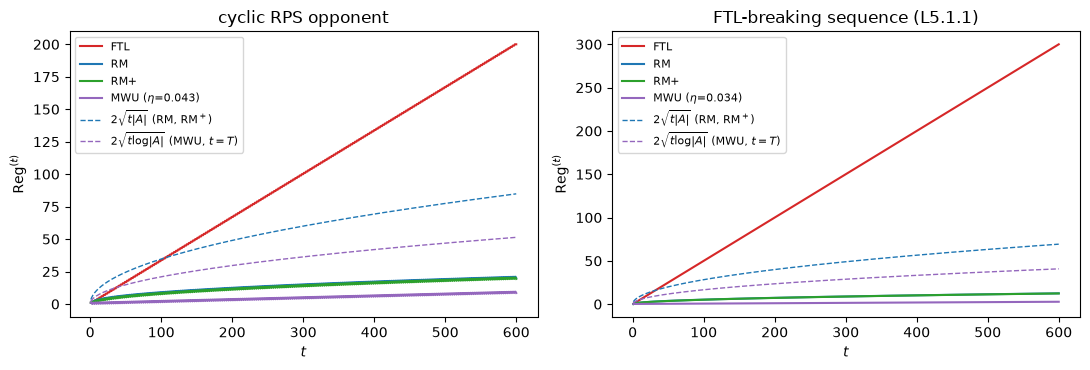

In [5]:
def simulate(gs, algo, eta=None):
    # Float version of the same learners. Returns the strategies x^(1), ..., x^(T).
    gs = np.asarray(gs, dtype=float)
    T, n = gs.shape
    r = np.zeros(n)
    G = np.zeros(n)
    xs = []
    for g in gs:
        if algo == "FTL":
            x = np.zeros(n); x[int(np.argmax(G))] = 1.0  # argmax breaks ties lexicographically
        elif algo in ("RM", "RM+"):
            pos = np.maximum(r, 0)
            x = pos / pos.sum() if pos.sum() > 0 else np.full(n, 1 / n)
        elif algo == "MWU":
            z = eta * (G - G.max())  # = softmax(eta r), see Section L5.1.5
            x = np.exp(z) / np.exp(z).sum()
        u = g @ x
        r = r + g - u
        if algo == "RM+":
            r = np.maximum(r, 0)
        G = G + g
        xs.append(x)
    return np.array(xs)

def regret_curve(gs, xs):
    gs = np.asarray(gs, dtype=float)
    G = np.cumsum(gs, axis=0)
    U = np.cumsum((gs * xs).sum(axis=1))
    return G.max(axis=1) - U

def cyclic(T):
    return [PAYOFF["RPS"[t % 3]] for t in range(T)]

def ftl_breaker(T):
    return [(0, 0.5)] + [((1, 0) if t % 2 else (0, 1)) for t in range(1, T)]

T = 600
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (name, seq) in zip(axes, [("cyclic RPS opponent", cyclic(T)), ("FTL-breaking sequence (L5.1.1)", ftl_breaker(T))]):
    n = len(seq[0])
    ts = np.arange(1, T + 1)
    for algo, style in [("FTL", "C3"), ("RM", "C0"), ("RM+", "C2"), ("MWU", "C4")]:
        eta = math.sqrt(math.log(n) / T)
        xs = simulate(seq, algo, eta)
        ax.plot(ts, regret_curve(seq, xs), style, label=algo if algo != "MWU" else f"MWU ($\\eta$={eta:.3f})")
    ax.plot(ts, 2 * np.sqrt(ts * n), "C0--", lw=1, label=r"$2\sqrt{t|A|}$ (RM, RM$^+$)")
    ax.plot(ts, 2 * np.sqrt(ts * math.log(n)), "C4--", lw=1, label=r"$2\sqrt{t\log|A|}$ (MWU, $t=T$)")
    ax.set_title(name); ax.set_xlabel("$t$"); ax.set_ylabel(r"Reg$^{(t)}$")
    ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

Against both opponents, follow-the-leader's regret grows linearly. Against the cyclic opponent, FTL ties twice and then loses once in every block of three rounds (exactly as in rounds 1 to 3 of the example), while every fixed action breaks even, so FTL's regret grows like $T/3$. Meanwhile RM, RM$^+$ and MWU stay well below their $O(\sqrt{T})$ guarantees. (The MWU guarantee is stated for the horizon $T$ used to tune $\eta$, so the dashed MWU curve is only meaningful at $t = T$.)

## 3. Interactive: how $\eta$ shapes MWU

Drag the slider to change $\eta$. Small $\eta$ keeps MWU near the uniform strategy; large $\eta$ makes it behave like follow-the-leader, jumping between corners. The plot shows the first $T$ iterates against the cyclic opponent, on the simplex with corners R, P, S as in Figure L5.1. If `ipywidgets` is not installed, the cell draws a few fixed values of $\eta$ instead.

In [6]:
CORNERS = np.array([[0.0, 0.0], [0.5, math.sqrt(3) / 2], [1.0, 0.0]])  # R, P, S

def draw_simplex(ax, xs, color, label):
    ax.plot(*np.vstack([CORNERS, CORNERS[:1]]).T, color="0.6", lw=1)
    for name, c, off in zip(ACTIONS, CORNERS, [(-0.05, -0.05), (0, 0.04), (0.03, -0.05)]):
        ax.text(c[0] + off[0], c[1] + off[1], name, ha="center")
    pts = xs @ CORNERS
    ax.plot(pts[:, 0], pts[:, 1], "-o", color=color, ms=3, lw=1, label=label)
    ax.plot(*pts[0], "o", color="k", ms=4)
    ax.set_aspect("equal"); ax.axis("off")

def mwu_vs_rm(eta=0.69, T=12):
    seq = cyclic(T)
    fig, ax = plt.subplots(1, 2, figsize=(8, 3.6))
    draw_simplex(ax[0], simulate(seq, "RM"), "C0", "RM")
    ax[0].set_title("Regret Matching (no parameter)")
    draw_simplex(ax[1], simulate(seq, "MWU", eta), "C4", "MWU")
    ax[1].set_title(f"MWU, $\\eta$ = {eta:.2f}")
    plt.show()

try:
    from ipywidgets import interact, FloatLogSlider, IntSlider
    interact(mwu_vs_rm, eta=FloatLogSlider(value=0.69, base=10, min=-2, max=1.5, step=0.05),
             T=IntSlider(value=12, min=3, max=60))
except ImportError:
    for eta in (0.1, math.log(2), 5.0):
        mwu_vs_rm(eta)

interactive(children=(FloatLogSlider(value=0.69, description='eta', max=1.5, min=-2.0, step=0.05), IntSlider(v…